In [12]:
# Association of exercise (hrs/week) with weight (kg) and resting heart rate (bpm)

import numpy as np
import pandas as pd

# 1. Generate random data

np.random.seed(42)  # for reproducibility

n = 20
exercise = np.random.normal(loc=4, scale=1.5, size=n)  # avg 4 hrs/week, some variation
exercise = np.clip(exercise, 0, None)  # no negative hours

# weight decreases with exercise, plus some random noise
weight = 80 - (2.5 * exercise) + np.random.normal(0, 3, size=n)

# resting heart rate depends on both exercise and weight
resting_hr = 75 - (1.0 * exercise) - (0.3 * weight) + np.random.normal(0, 2, size=n)

# wrap into DataFrame
df = pd.DataFrame({
    'Exercise_hrs_per_week': exercise,
    'Weight_kg': weight,
    'Resting_Heart_Rate_bpm': resting_hr
})

df


,Exercise_hrs_per_week,Weight_kg,Resting_Heart_Rate_bpm
0,4.745071,72.534268,49.971581
1,3.792604,69.841162,50.597784
2,4.971533,67.773753,49.465045
3,6.284545,60.014393,50.108930
4,3.648770,69.244927,47.620708
5,3.648795,71.210781,48.548283
6,6.368819,60.624971,49.522412
7,5.151152,68.249214,51.488328
8,3.295788,69.958613,51.403864
9,4.813840,67.090319,46.532984


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Plotting bivariate correlations for exercise and weight / heart rate

# Step 2: Calculate correlations
r_ex_weight, _ = pearsonr(df['Exercise_hrs_per_week'], df['Weight_kg'])
r_ex_hr, _ = pearsonr(df['Exercise_hrs_per_week'], df['Resting_Heart_Rate_bpm'])
r_weight_hr, _ = pearsonr(df['Weight_kg'], df['Resting_Heart_Rate_bpm'])

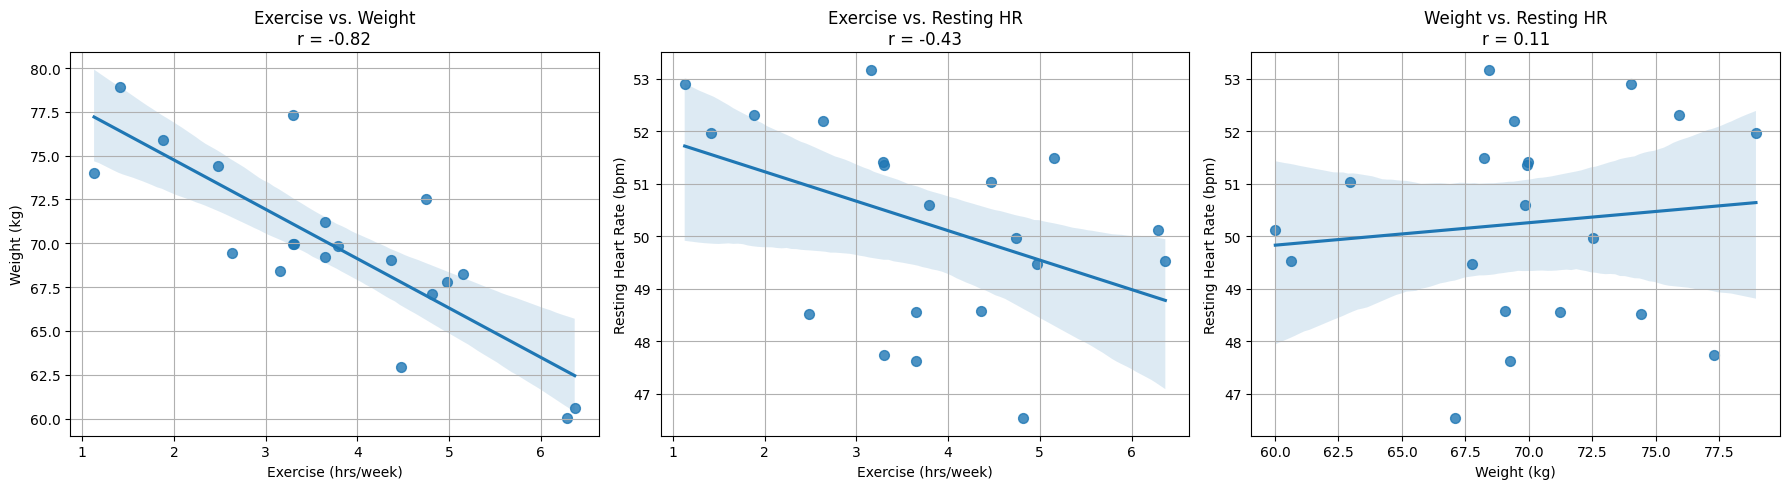

In [18]:
# Step 3: Plot all 3 bivariate correlations
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Exercise vs Weight
sns.regplot(x='Exercise_hrs_per_week', y='Weight_kg', data=df, ax=axs[0], scatter_kws={"s": 50})
axs[0].set_title(f"Exercise vs. Weight\nr = {r_ex_weight:.2f}")
axs[0].set_xlabel("Exercise (hrs/week)")
axs[0].set_ylabel("Weight (kg)")

# Plot 2: Exercise vs HR
sns.regplot(x='Exercise_hrs_per_week', y='Resting_Heart_Rate_bpm', data=df, ax=axs[1], scatter_kws={"s": 50})
axs[1].set_title(f"Exercise vs. Resting HR\nr = {r_ex_hr:.2f}")
axs[1].set_xlabel("Exercise (hrs/week)")
axs[1].set_ylabel("Resting Heart Rate (bpm)")

# Plot 3: Weight vs HR
sns.regplot(x='Weight_kg', y='Resting_Heart_Rate_bpm', data=df, ax=axs[2], scatter_kws={"s": 50})
axs[2].set_title(f"Weight vs. Resting HR\nr = {r_weight_hr:.2f}")
axs[2].set_xlabel("Weight (kg)")
axs[2].set_ylabel("Resting Heart Rate (bpm)")

# Format
for ax in axs:
    ax.grid(True)

plt.tight_layout()
plt.show()

In [22]:
import statsmodels.api as sm

# 4. Multiple regression models

# Define predictors and outcome
X = df['Exercise_hrs_per_week']
X = sm.add_constant(X)  # add intercept
y = df['Resting_Heart_Rate_bpm']

# Fit model
model1 = sm.OLS(y, X).fit()

# Summary output
print(model1.summary())

# Define predictors and outcome
X = df[['Exercise_hrs_per_week', 'Weight_kg']]
X = sm.add_constant(X)  # add intercept
y = df['Resting_Heart_Rate_bpm']

# Fit model
model2 = sm.OLS(y, X).fit()

# Summary output
print(model2.summary())


                              OLS Regression Results                              
Dep. Variable:     Resting_Heart_Rate_bpm   R-squared:                       0.181
Model:                                OLS   Adj. R-squared:                  0.136
Method:                     Least Squares   F-statistic:                     3.989
Date:                    Wed, 25 Jun 2025   Prob (F-statistic):             0.0611
Time:                            13:01:32   Log-Likelihood:                -38.666
No. Observations:                      20   AIC:                             81.33
Df Residuals:                          18   BIC:                             83.32
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [24]:
#5. Check variance influence factor (VIF) for predictors

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Prepare the design matrix (without constant)
X = df[['Exercise_hrs_per_week', 'Weight_kg']]

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                 feature       VIF
0  Exercise_hrs_per_week  6.092915
1              Weight_kg  6.092915


In [31]:
# Demonstrating effectiveness of VIF for collinearity detection

np.random.seed(123)
n = 100

# Generate independent variables
X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = np.random.normal(0, 1, n)

# Create variables that are linear combinations plus noise (introducing multicollinearity)
X4 = 0.7 * 1 + 0.3 * X2 + np.random.normal(0, 0.1, n)
X5 = 0.5 * 1 + 0.5 * X1 + np.random.normal(0, 0.1, n)
X6 = 0.6 * 1 + 0.4 * X3 + np.random.normal(0, 0.1, n)

df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'X4': X4,
    'X5': X5,
    'X6': X6
})

print(df.head())

# Calculate VIF for each feature
X = df  # Using all 6 variables as predictors

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

         X1        X2        X3        X4        X5        X6
0 -1.085631  0.642055  0.703310  0.969122  0.110594  0.956527
1  0.997345 -1.977888 -0.598105  0.023735  0.945681  0.367722
2  0.282978  0.712265  2.200702  0.847764  0.592392  1.453736
3 -1.506295  2.598304  0.688297  1.540604 -0.384064  0.968277
4 -0.578600 -0.024626 -0.006307  0.678211  0.209834  0.723559
  feature        VIF
0      X1  28.361557
1      X2   8.019692
2      X3  10.887418
3      X4  41.261943
4      X5  51.035206
5      X6  33.907718


In [34]:
# X4, X5, X6 are linear combinations of X1, X2, X3
# causing huge multi collinearity issues
# VIF should ideally be less than 5 for reasonably good independence of predictors

In [31]:
# Simulation of probability distributions and the central limit theorem

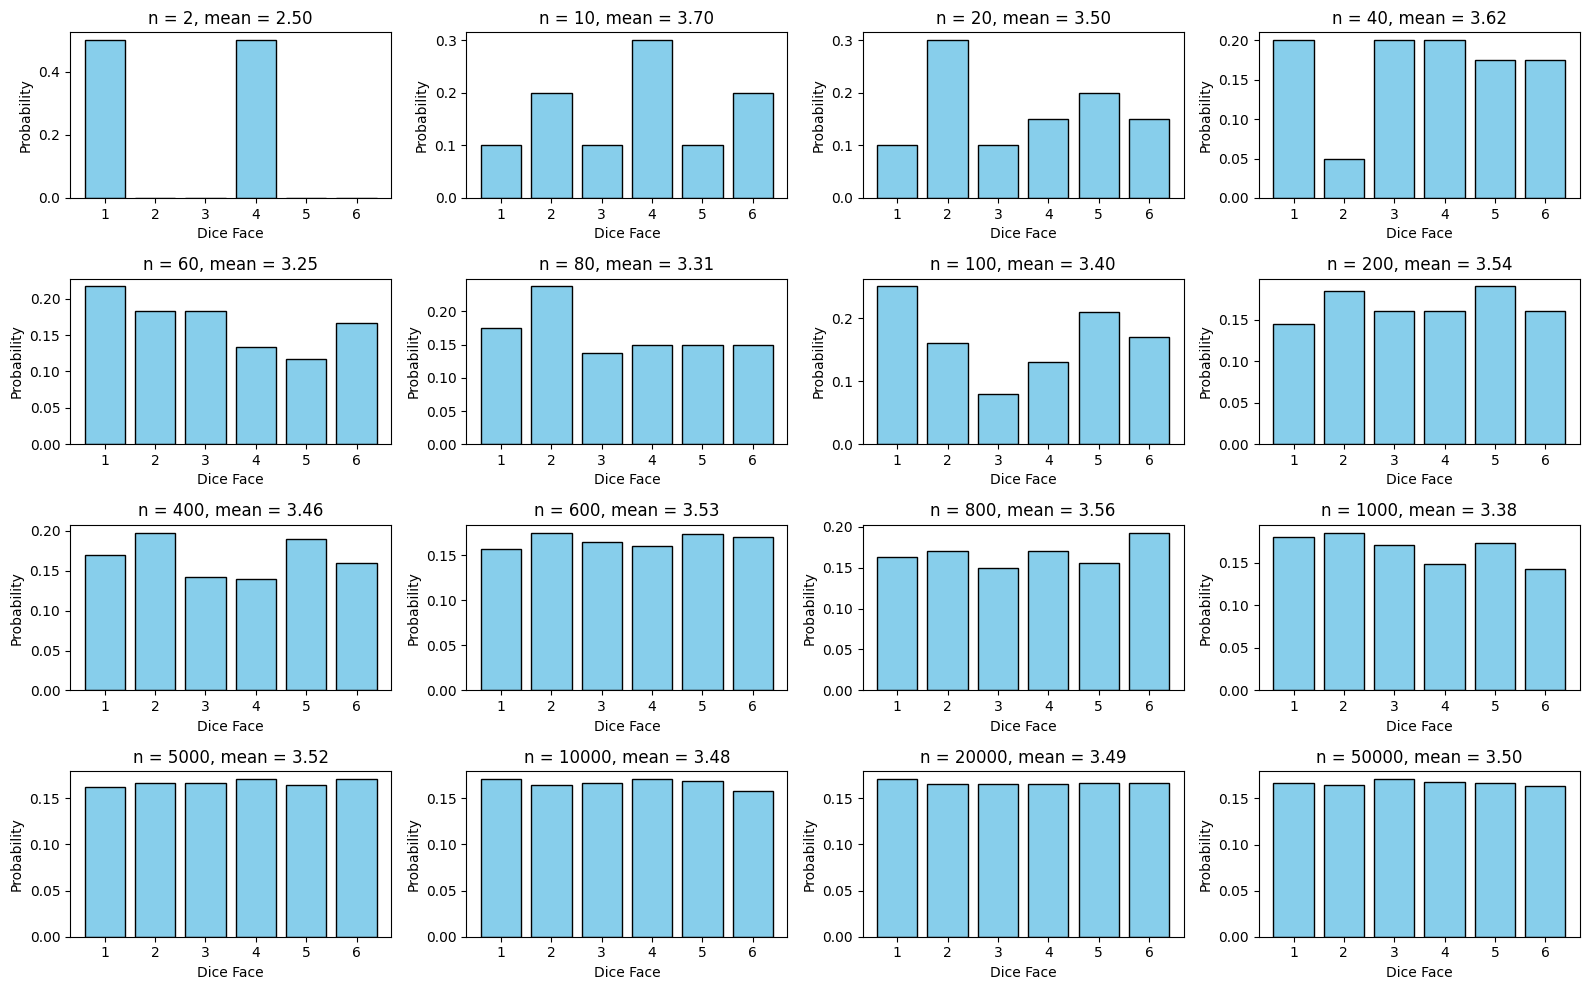

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(23)

# Example 1: Dice rolling as a uniform distribution

# Visualizing the uniform distribution of different sample sizes

# Define sample sizes
sample_sizes = [2, 10, 20, 40, 60, 80, 100, 200, 400, 600, 800, 1000, 5000, 10000, 20000, 50000]

# Set up subplots (4 rows x 4 columns for 16 cases)
fig, axes = plt.subplots(4, 4, figsize=(16, 10))
axes = axes.flatten()

for i, n in enumerate(sample_sizes):
    # Roll n dice
    sample = np.random.randint(1, 7, size=n)
    mean_val = np.mean(sample)
    
    # Plot histogram
    axes[i].hist(sample, bins=np.arange(1, 8)-0.5, density=True, 
                 rwidth=0.8, color='skyblue', edgecolor='black')
    axes[i].set_title(f"n = {n}, mean = {mean_val:.2f}")
    axes[i].set_xlabel("Dice Face")
    axes[i].set_ylabel("Probability")
    axes[i].set_xticks(range(1, 7))

plt.tight_layout()
plt.show()



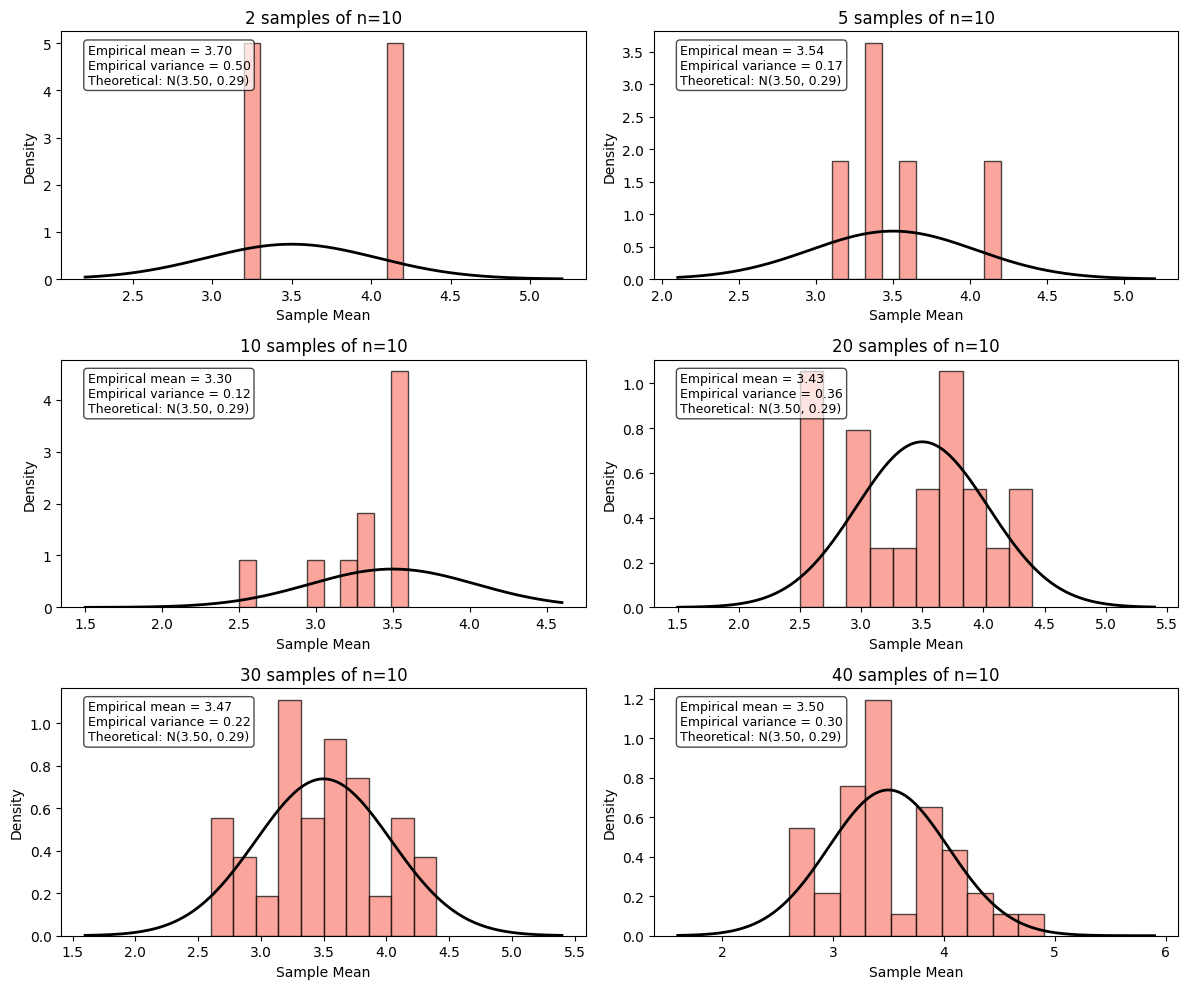

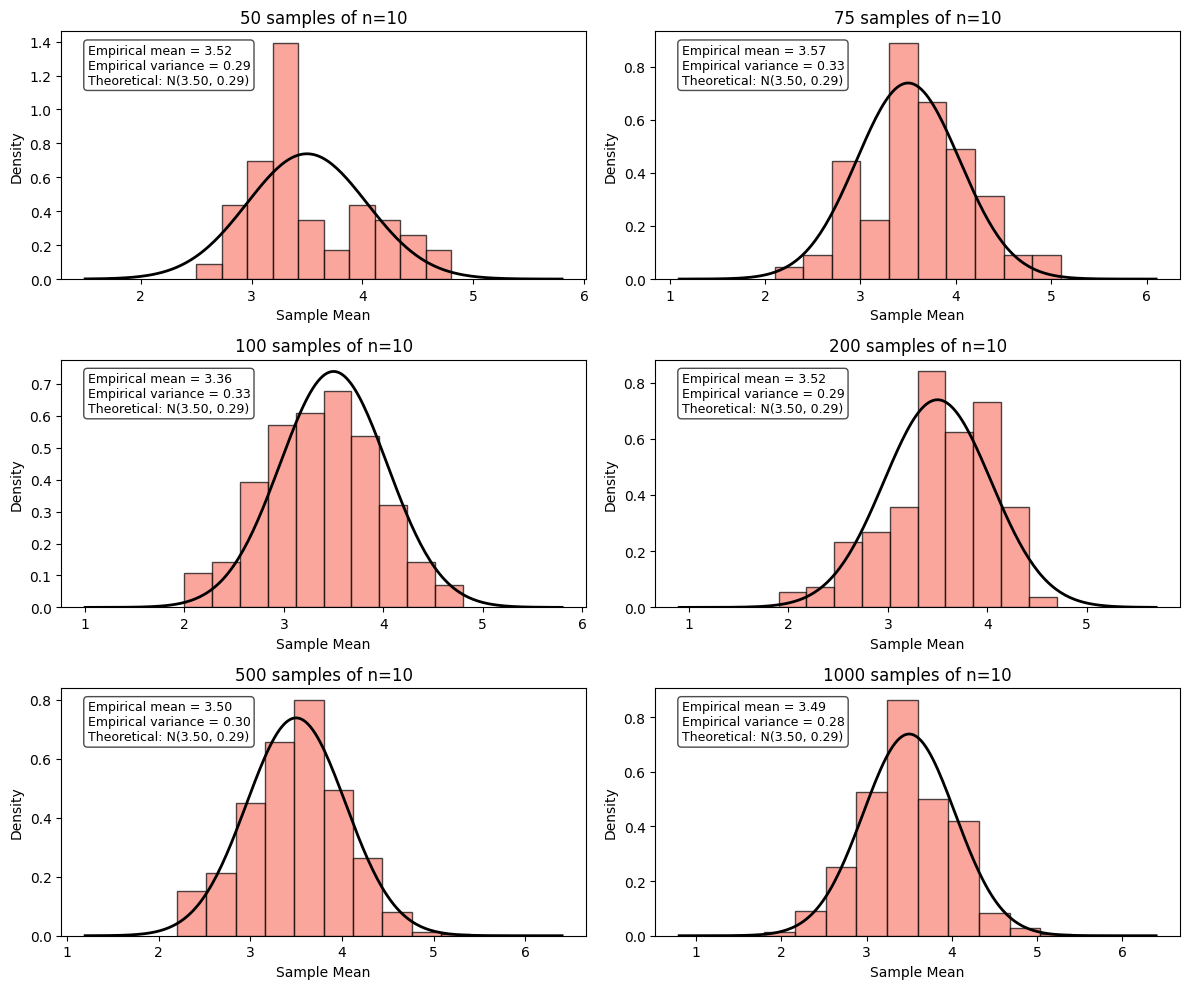

In [70]:
np.random.seed(23)

# Define a sample size of 10 rolls

# Make multiple samples, compute their means and visualize to make the normal distribution of sample means emerge -> CLT

# Parameters
sample_size = 10  # number of dice per sample
num_samples_list = [2, 5, 10, 20, 30, 40, 50, 75, 100, 200, 500, 1000]

# Theoretical distribution parameters for dice
mu = 3.5
sigma2 = 35/12                # variance of single die
sigma = np.sqrt(sigma2 / sample_size)  # std dev of sample mean

# Split the list into two halves for two figures
halves = [num_samples_list[:6], num_samples_list[6:]]

for half_idx, half_list in enumerate(halves):
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, num_samples in enumerate(half_list):
        means = []
        for _ in range(num_samples):
            sample = np.random.randint(1, 7, size=sample_size)
            means.append(np.mean(sample))
        means = np.array(means)
        
        # Empirical stats
        mean_of_means = np.mean(means)
        var_of_means = np.var(means, ddof=1)
        
        # Plot histogram
        ax = axes[i]
        ax.hist(means, bins=10, density=True, color='salmon', edgecolor='black', alpha=0.7)
        
        # Overlay normal distribution
        x = np.linspace(min(means)-1, max(means)+1, 200)
        y = norm.pdf(x, loc=mu, scale=sigma)
        ax.plot(x, y, 'k-', lw=2)
        
        # Annotation
        textstr = (f"Empirical mean = {mean_of_means:.2f}\n"
                   f"Empirical variance = {var_of_means:.2f}\n"
                   f"Theoretical: N(3.50, 0.29)")
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
        
        ax.set_title(f"{num_samples} samples of n={sample_size}")
        ax.set_xlabel("Sample Mean")
        ax.set_ylabel("Density")
    
    plt.tight_layout()
    plt.show()

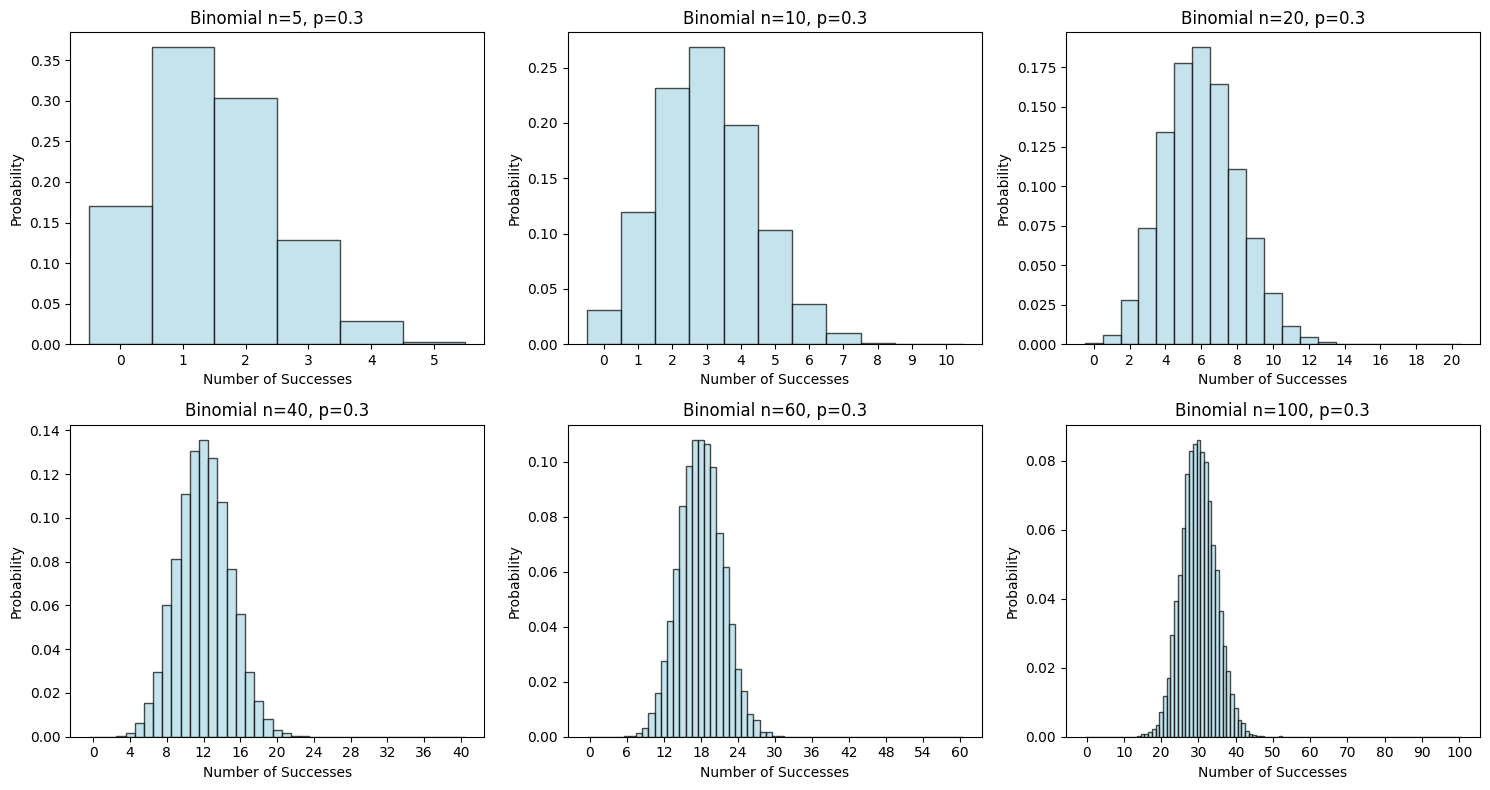

In [71]:
np.random.seed(23)

# Demonstrating CLT with the Binomial distribution

from scipy.stats import binom

# Different numbers of trials
trial_sizes = [5, 10, 20, 40, 60, 100]
p = 0.3
num_draws = 10000  # number of binomial random variables per trial size

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, n in enumerate(trial_sizes):
    # Simulate binomial draws
    data = np.random.binomial(n, p, size=num_draws)
    
    # Plot histogram
    ax = axes[i]
    ax.hist(data, bins=np.arange(-0.5, n+1.5, 1), density=True, 
            edgecolor='black', color='lightblue', alpha=0.7)
    
    ax.set_title(f"Binomial n={n}, p={p}")
    ax.set_xlabel("Number of Successes")
    ax.set_ylabel("Probability")
    ax.set_xticks(range(0, n+1, max(1, n//10)))

plt.tight_layout()
plt.show()

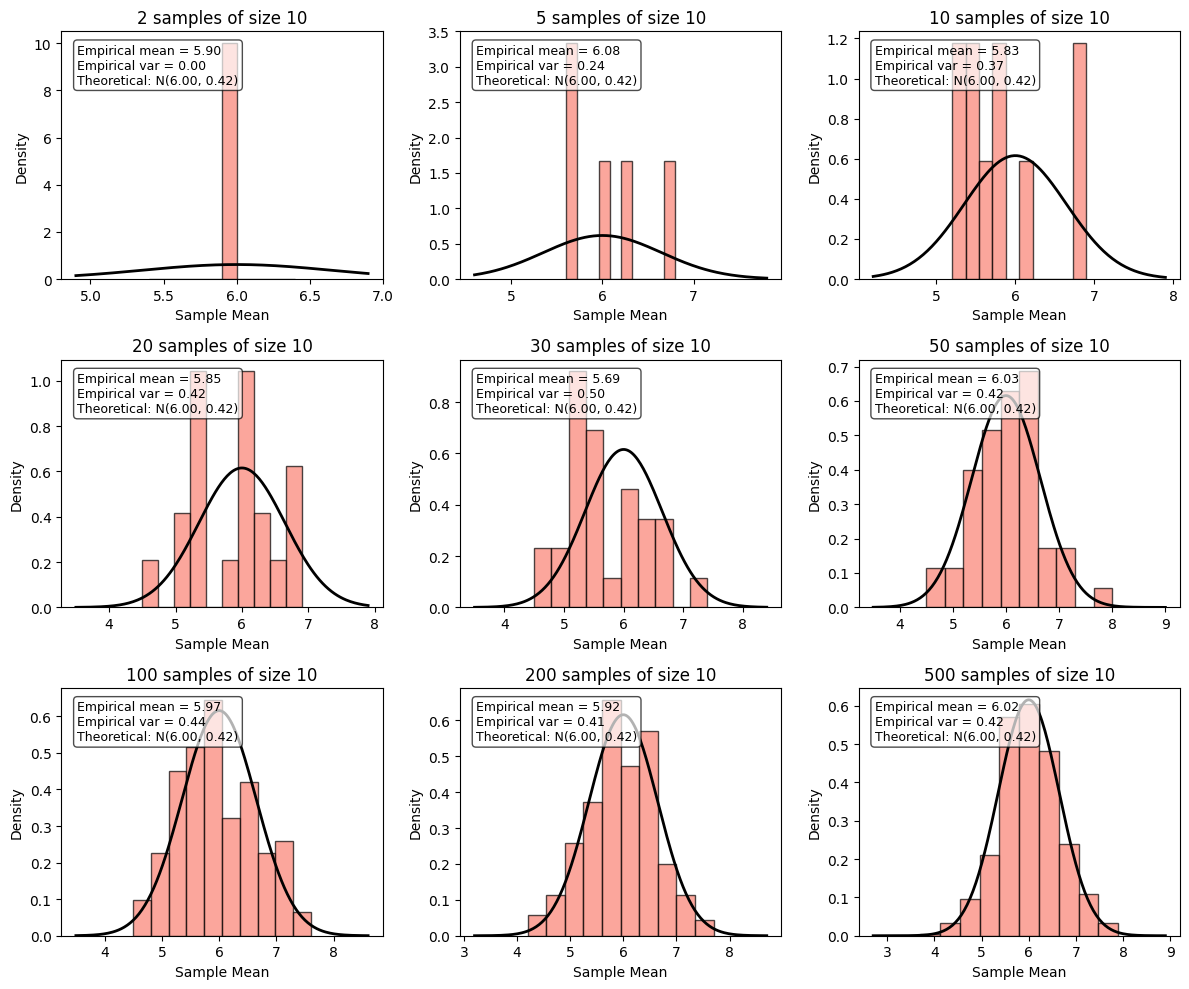

In [72]:
np.random.seed(23)

# Parameters
n_trials = 20       # trials per binomial draw
p = 0.3             # success probability
sample_size = 10    # number of binomial draws per sample
num_samples_list = [2, 5, 10, 20, 30, 50, 100, 200, 500]  # repetitions

# Theoretical mean and std of sample mean
mu = n_trials * p
sigma = np.sqrt(n_trials * p * (1-p) / sample_size)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, num_samples in enumerate(num_samples_list):
    sample_means = []
    
    for _ in range(num_samples):
        # Take a sample of `sample_size` binomial draws
        sample = np.random.binomial(n_trials, p, size=sample_size)
        sample_means.append(np.mean(sample))
    
    sample_means = np.array(sample_means)
    
    # Empirical statistics
    mean_of_means = np.mean(sample_means)
    var_of_means = np.var(sample_means, ddof=1)
    
    # Plot histogram of sample means
    ax = axes[i]
    ax.hist(sample_means, bins=10, density=True, color='salmon', edgecolor='black', alpha=0.7)
    
    # Overlay theoretical normal distribution
    x = np.linspace(min(sample_means)-1, max(sample_means)+1, 200)
    y = norm.pdf(x, loc=mu, scale=sigma)
    ax.plot(x, y, 'k-', lw=2)
    
    # Annotation
    textstr = (f"Empirical mean = {mean_of_means:.2f}\n"
               f"Empirical var = {var_of_means:.2f}\n"
               f"Theoretical: N({mu:.2f}, {sigma**2:.2f})")
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
    
    ax.set_title(f"{num_samples} samples of size {sample_size}")
    ax.set_xlabel("Sample Mean")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

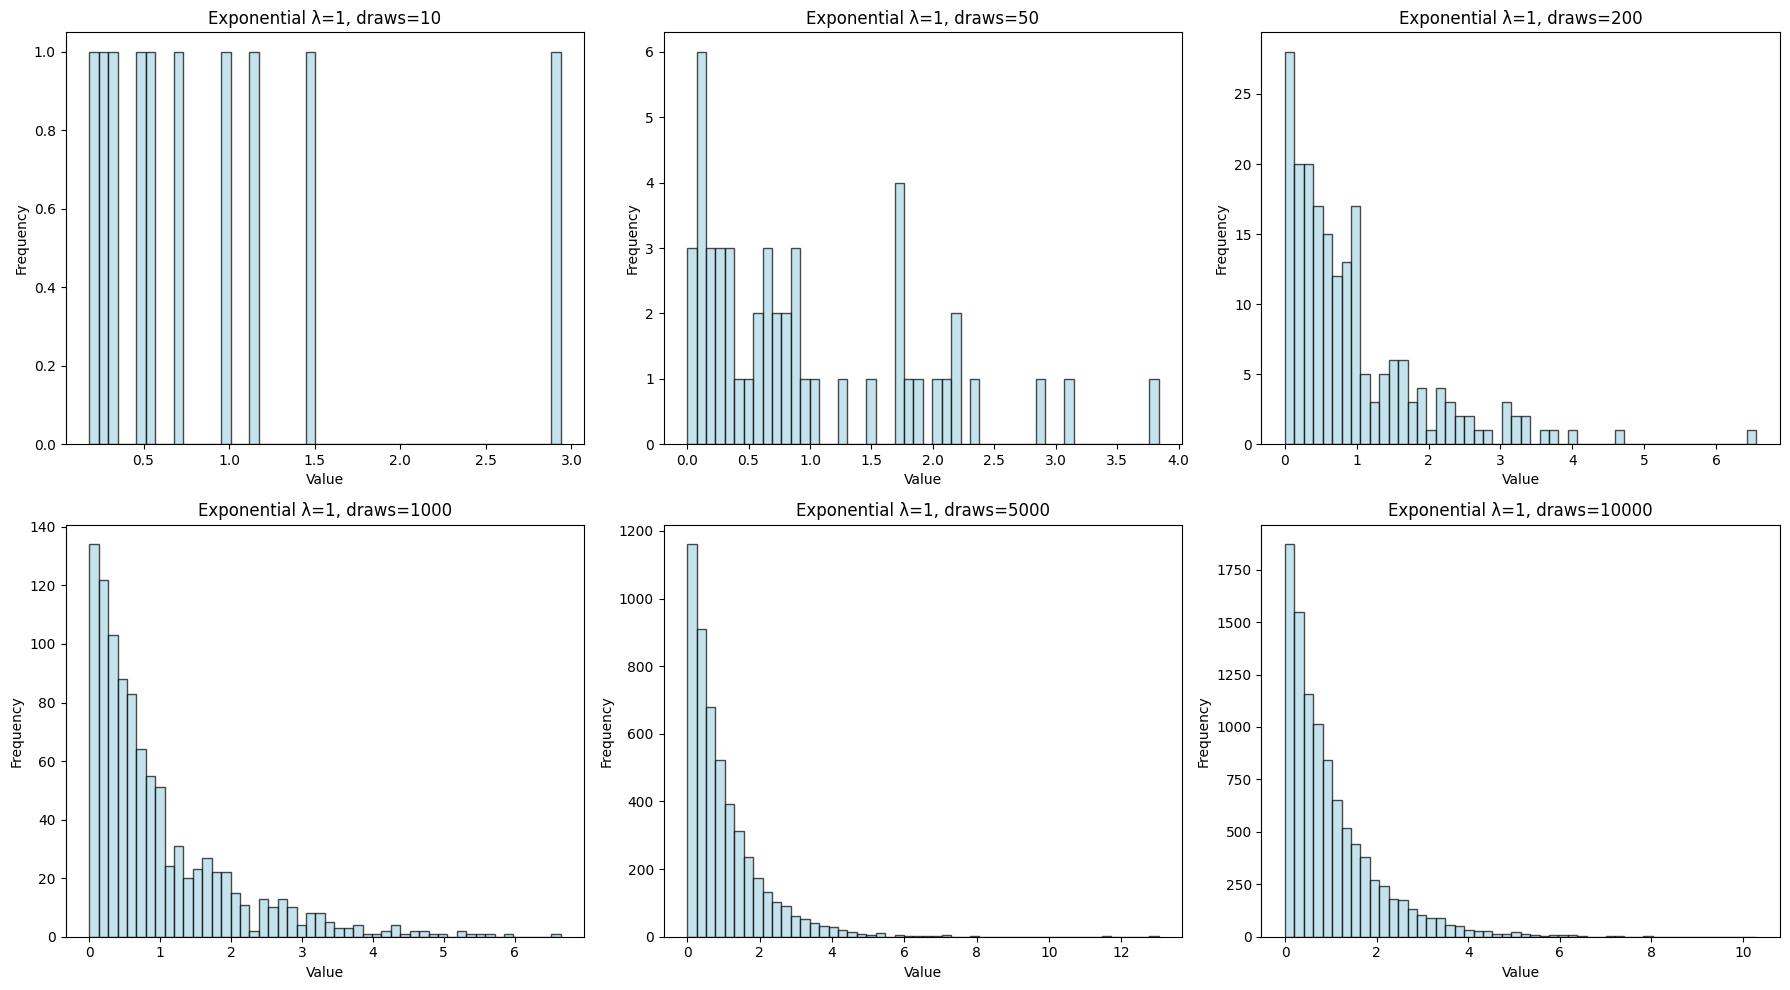

In [80]:
# Simulating exponential distribution!

np.random.seed(23)


# Fixed lambda
lam = 1

# Different numbers of draws
num_draws_list = [10, 50, 200, 1000, 5000, 10000]

# Create 2x3 subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, num_draws in enumerate(num_draws_list):
    # Simulate exponential draws
    data = np.random.exponential(scale=1/lam, size=num_draws)
    
    # Plot histogram of raw draws
    ax = axes[i]
    ax.hist(data, bins=50, color='lightblue', edgecolor='black', alpha=0.7)
    
    ax.set_title(f"Exponential λ={lam}, draws={num_draws}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

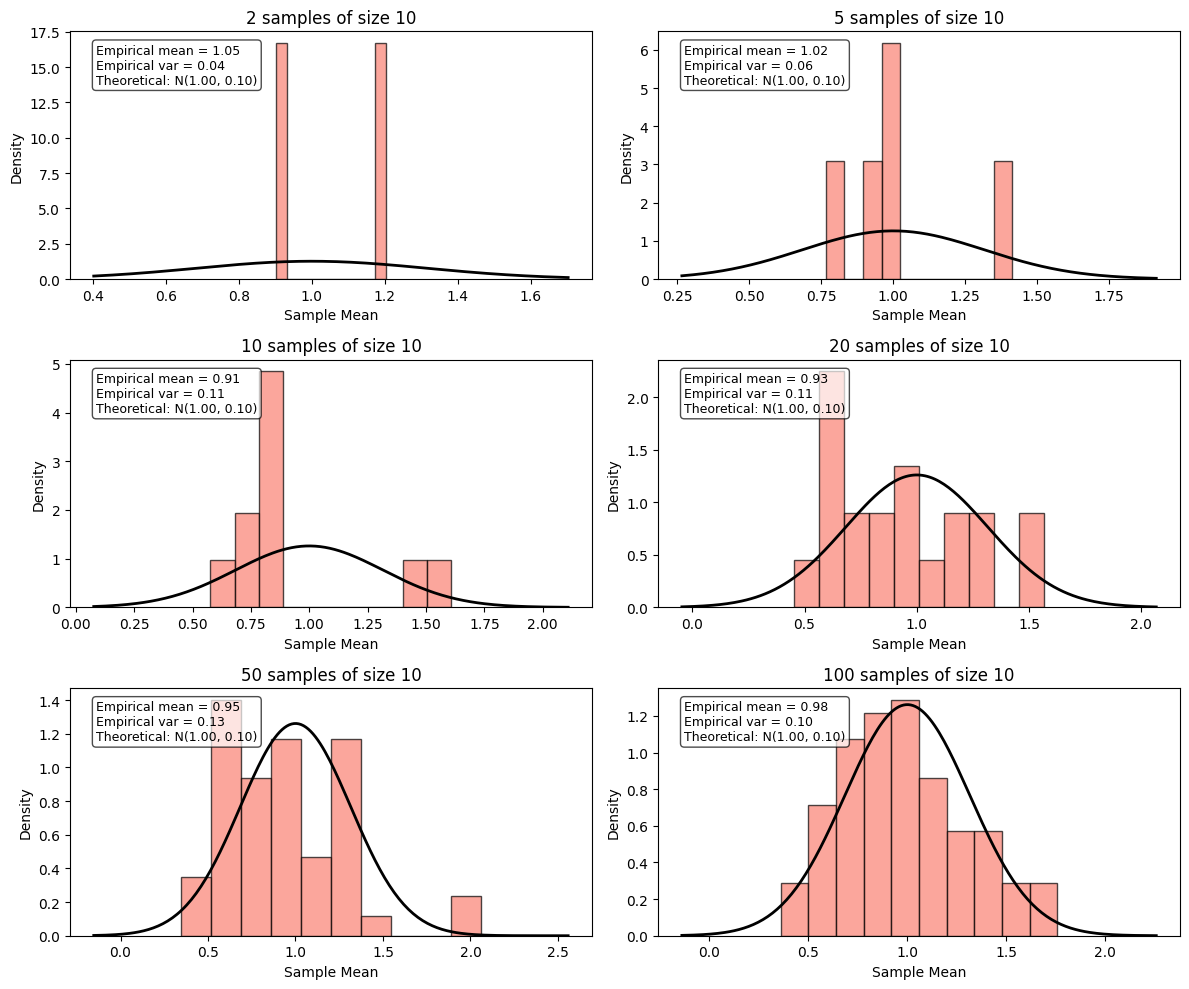

In [81]:
# CLT for exponential distribution!

np.random.seed(23)

# Parameters
lam = 1                # rate parameter
sample_size = 10       # number of draws per sample
num_samples_list = [2, 5, 10, 20, 50, 100]  # number of repeated samples

# Theoretical mean and std of sample mean
mu = 1/lam
sigma = (1/lam) / np.sqrt(sample_size)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, num_samples in enumerate(num_samples_list):
    sample_means = []
    
    for _ in range(num_samples):
        sample = np.random.exponential(scale=1/lam, size=sample_size)
        sample_means.append(np.mean(sample))
    
    sample_means = np.array(sample_means)
    
    mean_of_means = np.mean(sample_means)
    var_of_means = np.var(sample_means, ddof=1)
    
    # Plot histogram of sample means
    ax = axes[i]
    ax.hist(sample_means, bins=10, density=True, color='salmon', edgecolor='black', alpha=0.7)
    
    # Overlay theoretical normal distribution
    x = np.linspace(min(sample_means)-0.5, max(sample_means)+0.5, 200)
    y = norm.pdf(x, loc=mu, scale=sigma)
    ax.plot(x, y, 'k-', lw=2)
    
    # Annotation
    textstr = (f"Empirical mean = {mean_of_means:.2f}\n"
               f"Empirical var = {var_of_means:.2f}\n"
               f"Theoretical: N({mu:.2f}, {sigma**2:.2f})")
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
    
    ax.set_title(f"{num_samples} samples of size {sample_size}")
    ax.set_xlabel("Sample Mean")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()